In [2]:
# import external modules
import numpy, os

# Add Exasim to Python search path
cdir = os.getcwd(); ii = cdir.find("Exasim")
exec(open(cdir[0:(ii+6)] + "/install/setpath.py").read())

# import internal modules
import Preprocessing, Postprocessing, Gencode, Mesh
import netCDF4
import Utilities, PlotUtilities

==> Exasim frontends ...



In [4]:
# Create pde object and mesh object
pde,mesh = Preprocessing.initializeexasim()

# Define a PDE model: governing equations and boundary conditions
pde['model'] = "ModelD";       # ModelC, ModelD, ModelW
pde['modelfile'] = "pdemodel"; # name of a file defining the PDE model
pde['hybrid'] = 1;          # 0 -> LDG, 1 -> HDG

# Choose computing platform and set number of processors
pde['platform'] = "gpu"
pde['mpiprocs'] = 4
pde['cpucompiler']  = "CC"
pde['mpicompiler'] = "CC"
pde['gpucompiler'] = cdir[0:(ii+6)] + "/kokkos/bin/nvcc_wrapper" # e.g. /path_to_kokkos/bin/nvcc_wrapper

# Set discretization parameters, physical parameters, and solver parameters
pde['nd'] = 3
pde['porder'] = 2;         # polynomial degree
pde['pgauss'] = 2*pde['porder'] # number of Gauss points for quadrature
pde['tau'] = numpy.array([2.0]);            # DG stabilization parameter
pde['GMRESrestart'] = 250; # GMRES restart parameter
pde['GMRESortho'] = 1
pde['linearsolvertol'] = 1e-6; # linear solver tolerance
pde['linearsolveriter'] = 500
pde['preconditioner'] = 1
pde['ppdegree'] = 0; # degree of polynomial precontiditoning
pde['RBdim'] = 0; # reduced basis dimension for preconditioner
pde['NLtol'] = 1e-7; # nonlinear solver tolerance
pde['NLiter'] = 10; # number of nonlinear iterations
pde['matvectol'] = 1e-6; # matrix-vector product tolerance

# Physical parameters
dt0 = 60.0  # time step size in seconds

Re = 6378e3
hL = 100e3; hT = 600e3

gam = 5/3
m = 16*1.67e-27
kB = 1.38e-23
e = 1.602e-19
g0 = 9.81*Re*Re/(Re + hL)**2
omega = 2*numpy.pi/86400
T0 = 200.0
H0 = kB*T0/(m*g0)
v0 = numpy.sqrt(gam*kB*T0/m)
t0 = H0/v0
B0 = 1e-8
E0 = B0*v0
nu0 = 6000

# Nondimensional parameters
R0 = (Re + hL)/H0
R1 = (Re + hT)/H0

Ro = v0/(omega*H0)
piE = e*E0/(gam*m*g0)
piB = e*B0*v0/(gam*m*g0)
piNu = nu0*H0/v0
piChem = 0.0 # Ch0*H0/v0
Diff = 0.0 # kappa0/(n0*kB*v0*H0)
piP = 0.0 # P0*H0/(v0*T0)

pde['physicsparam'] = numpy.array([gam, Ro, piE, piB, piNu, piChem, Diff, piP, R0, R1, H0])
                                  #  0,  1,   2,   3,    4,      5,    6,    7,  8,  9, 10

# Time-stepping parameters
pde['torder'] = 1;          # time-stepping order of accuracy
pde['nstage'] = 1;          # time-stepping number of stages
pde['dt'] = (dt0/t0)*numpy.ones(10);   # time step sizes
pde['soltime'] = numpy.arange(1,pde['dt'].size+1,1); # steps at which solution are collected
pde['visdt'] = 1.0; # visualization timestep size

# Mesh generation
# mesh['p'], mesh['t'], mesh['dgnodes'] = Mesh.cubesphere(pde['porder'],R0,R1,16,10)
hDiv = 18 #horizontal divisions
nDiv = 1 # number of grid elements per scale height
mesh['p'], mesh['t'], mesh['dgnodes'] = Mesh.cubesphere_scaleheight(pde['porder'], hDiv, nDiv, hL, hT, H0)
mesh['boundaryexpr'] = [
    lambda p: abs(p[0,:]**2 + p[1,:]**2 + p[2,:]**2 - R0**2) < 1e-6,
    lambda p: abs(p[0,:]**2 + p[1,:]**2 + p[2,:]**2 - R1**2) < 1e-6]
mesh['boundarycondition'] = numpy.array([1, 2]); # Set boundary condition for each boundary

# Defining dipole magnetic field (test)
npe, nd, ne = mesh['dgnodes'].shape
x1 = mesh['dgnodes'][:,0,:]; x2 = mesh['dgnodes'][:,1,:]; x3 = mesh['dgnodes'][:,2,:]
r = numpy.sqrt(x1**2 + x2**2 + x3**2)
Bx = 3*x1*x3/r**2; By = 3*x2*x3/r**2; Bz = (3*x3**2 - r**2)/r**2
Bx = Bx*(R0/r)**3; By = By*(R0/r)**3; Bz = Bz*(R0/r)**3


In [5]:
timeidx = 0
data = netCDF4.Dataset(filename='regrid/data.nc')
nalt = data.dimensions['alt'].size
nnode = data.dimensions['node'].size
nodeidx = data['nodeidx_out'][:].filled() - 1
altidx = data['altidx_out'][:].filled() - 1
BX = data['BX'][:].filled()/B0
BY = data['BY'][:].filled()/B0
BZ = data['BZ'][:].filled()/B0
EX = data['EX'][timeidx+1, :, :].filled()/E0
EY = data['EY'][timeidx+1, :, :].filled()/E0
EZ = data['EZ'][timeidx+1, :, :].filled()/E0
N = data['N'][timeidx+1, :, :].filled()
T = data['T'][timeidx+1, :, :].filled()/T0
NU = data['NU'][timeidx+1, :, :].filled()/nu0
UX = data['UX'][timeidx+1, :, :].filled()/v0
UY = data['UY'][timeidx+1, :, :].filled()/v0
UZ = data['UZ'][timeidx+1, :, :].filled()/v0
VX = data['VX'][timeidx, :, :].filled()/v0
VY = data['VY'][timeidx, :, :].filled()/v0
VZ = data['VZ'][timeidx, :, :].filled()/v0
data.close()

mesh['vdg'] = numpy.zeros((npe,18,ne))
for icell in range(ne):
    for inode in range(npe):
        mesh['vdg'][inode, 0, icell] = BX[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 1, icell] = BY[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 2, icell] = BZ[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 3, icell] = EX[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 4, icell] = EY[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 5, icell] = EZ[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 6, icell] = N[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 10, icell] = T[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 11, icell] = NU[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 12, icell] = UX[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 13, icell] = UY[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 14, icell] = UZ[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 15, icell] = VX[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 16, icell] = VY[altidx[inode, icell], nodeidx[inode, icell]]
        mesh['vdg'][inode, 17, icell] = VZ[altidx[inode, icell], nodeidx[inode, icell]]


xpe,telem,xpf,tface,perm = Preprocessing.masternodes(pde['porder'],pde['nd'],1)

gpe, gwe = Preprocessing.gaussnodes(pde['pgauss'],pde['nd'],pde['elemtype'])
gpe = numpy.array(gpe,float)
shapeg = Preprocessing.mkshape(pde['porder'],xpe,gpe,1)

for d in range(0,pde['nd']+1):
    shapeg[:,:,d] = shapeg[:,:,d].transpose()

mesh['vdg'][:,7:10,:] = Preprocessing.gradu(shapeg[:,:,1:4], mesh['dgnodes'], numpy.log(mesh['vdg'][:,6,:]))

Text(0.5, 1.0, 'Altitude: 600.0 km')

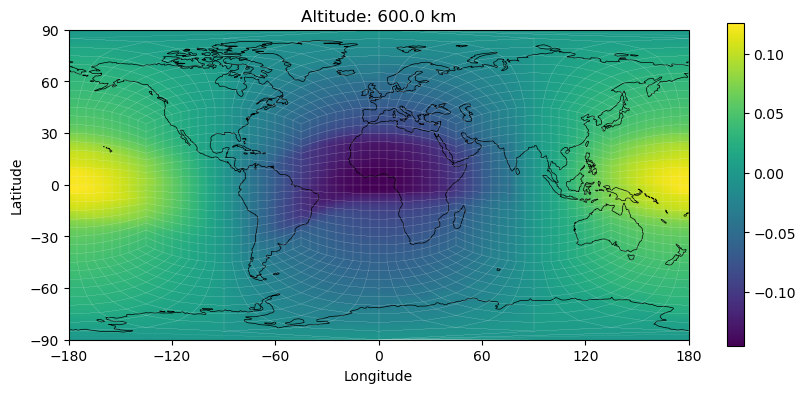

In [20]:
ilev = -1
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(mesh['dgnodes'],mesh['vdg'][:,7,:],pde,ilev)
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')

Text(0.5, 1.0, 'Altitude: 106.3 km')

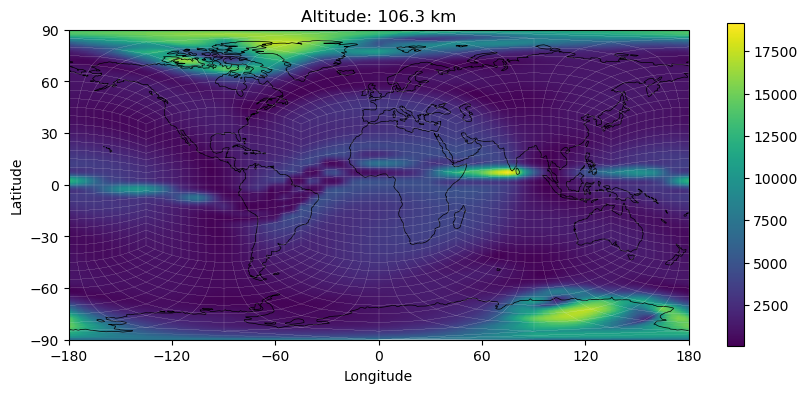

In [12]:
ilev = 2
# var = numpy.sqrt(mesh['vdg'][:,0,:]**2 + mesh['vdg'][:,1,:]**2 + mesh['vdg'][:,2,:]**2)
uimvi = numpy.sqrt((mesh['vdg'][:,12,:]-mesh['vdg'][:,15,:])**2 + (mesh['vdg'][:,13,:]-mesh['vdg'][:,16,:])**2 + (mesh['vdg'][:,14,:]-mesh['vdg'][:,17,:])**2)
var = piNu*mesh['vdg'][:,11,:]*(uimvi)
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(mesh['dgnodes'],var,pde,ilev)
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')